**NAME - GAURAV RAMESH GUPTA**
**ROLL NO. - 27**
**EXP - 8**
**BATCH - 2**
**DATE - 12/03/2026**

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans , AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram , linkage


In [2]:
def fetch_indicator (code , year="2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"

    response = requests.get(url).json()[1]

    data={}
    for item in response:
        country = item["country"]["value"]
        value=item["value"]
        if value is not None :
            data[country]=value

    return pd.Series(data,name=code)

In [3]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [4]:
df = pd.concat([gdp , pop , life , lit],axis=1)
df.columns = ["GDP","Population","LifeExpectancy","Literacy"]
#df.dropna(inplace=True)
df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Caribbean small states,17456.308485,4497310,72.832292,NaN
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919


In [19]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, Africa Eastern and Southern to Zambia
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GDP             84 non-null     float64
 1   Population      84 non-null     int64  
 2   LifeExpectancy  84 non-null     float64
 3   Literacy        84 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 5.3+ KB


In [21]:
df.describe()

,GDP,Population,LifeExpectancy,Literacy
count,84.000000,8.400000e+01,84.000000,84.000000
mean,8238.568060,8.926457e+08,70.763675,83.528910
std,11795.695978,1.621154e+09,6.093029,15.047212
min,573.141166,9.992000e+03,53.931000,35.610001
25%,1939.131563,1.103902e+07,65.642139,72.567499
50%,5034.058488,1.063451e+08,72.079287,87.609039
75%,9562.840930,1.064327e+09,74.963146,96.409626
max,74535.636539,7.989545e+09,85.708000,100.000000


In [22]:
df.shape

(84, 4)

In [23]:
scaler = StandardScaler()
x_scaled=scaler.fit_transform(df)

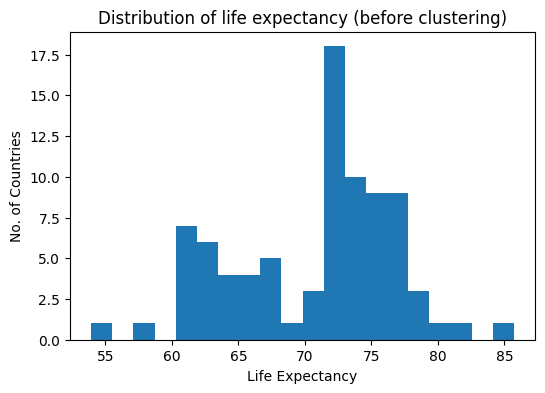

In [26]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"],bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("No. of Countries")
plt.title("Distribution of life expectancy (before clustering)")
plt.show()

**PART 2**

k	wcss
1	336.00000000000006
2	206.43717192603808
3	142.06028324967596
4	122.46400641421171
5	68.71234707726028
6	56.092718405819106
7	51.08265517326418
8	41.70851027024395
9	31.213863029560223
10	27.04725098650771


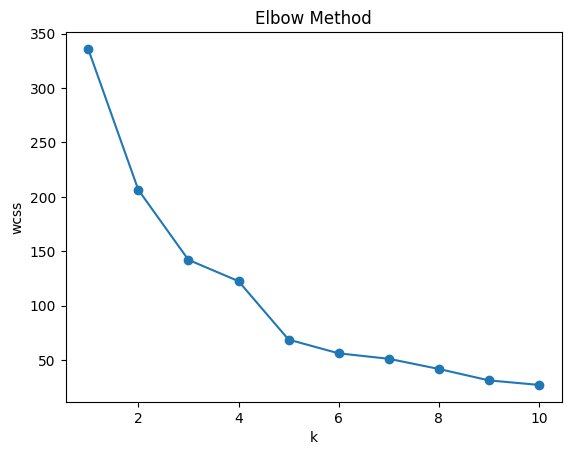

In [30]:
wcss =[]
for k in range(1,11):
  km = KMeans(n_clusters=k, random_state=0)
  km.fit(x_scaled)
  wcss.append(km.inertia_)

print("k\twcss")
for k_val, inertia_val in enumerate(wcss, 1):
    print(f"{k_val}\t{inertia_val}")

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("k")
plt.ylabel("wcss")
plt.title("Elbow Method")
plt.show()

**PART 3**

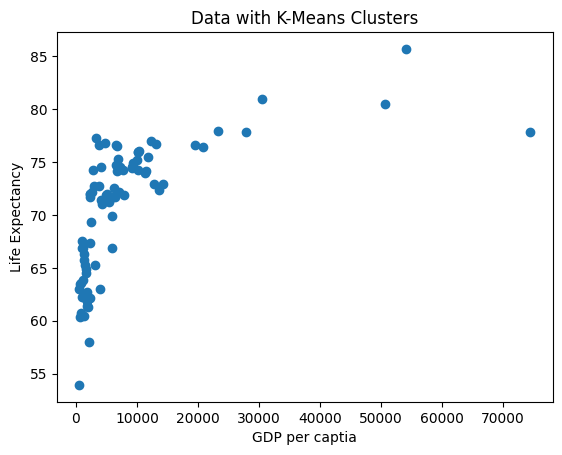

In [33]:
plt.scatter(df["GDP"],df["LifeExpectancy"], )
plt.xlabel("GDP per captia")
plt.ylabel("Life Expectancy")
plt.title("Data with K-Means Clusters")
plt.show()

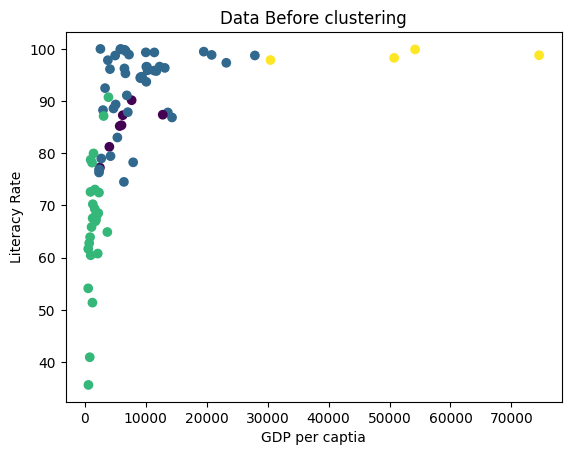

In [36]:
plt.scatter(df["GDP"],df["Literacy"], c=label_km)
plt.xlabel("GDP per captia")
plt.ylabel("Literacy Rate")
plt.title("Data Before clustering")
plt.show()

In [37]:
hc =  AgglomerativeClustering(n_clusters=3)
labels_hc=hc.fit_predict(x_scaled)
df["HierarchicalCluster"]=labels_hc

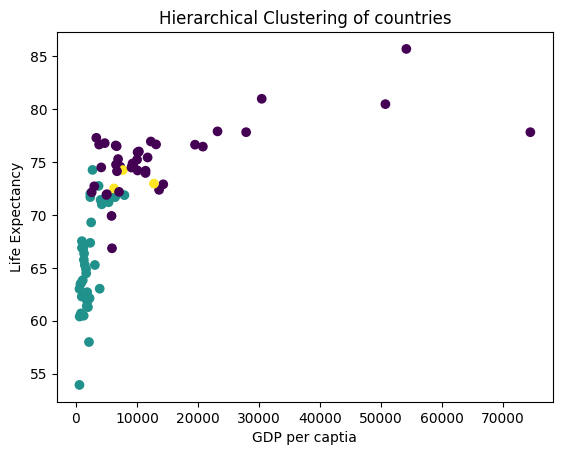

In [38]:
plt.scatter(df["GDP"],df["LifeExpectancy"], c=labels_hc)
plt.xlabel("GDP per captia")
plt.ylabel("Life Expectancy")
plt.title("Hierarchical Clustering of countries")
plt.show()

In [41]:
cluster_summary = df.groupby("KMeansCluster")[["GDP","Population","LifeExpectancy","Literacy"]].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               6437.349751  5.501554e+09       71.975830  84.851687
1               8714.806589  4.998677e+08       74.175331  92.395007
2               1601.971896  4.854521e+08       63.478867  66.779721
3              52489.189790  9.616286e+07       81.254942  98.714788


In [42]:
country_name="India"
result = df.loc[country_name]

print("Country:",country_name)
print("GDP per capita:",result["GDP"])
print("Population:",result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])

Country: India
GDP per capita: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242


In [43]:
country_name="Brazil"
result = df.loc[country_name]

print("Country:",country_name)
print("GDP per capita:",result["GDP"])
print("Population:",result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])

Country: Brazil
GDP per capita: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348


In [50]:
country_name="North America"
result = df.loc[country_name]

print("Country:",country_name)
print("GDP per capita:",result["GDP"])
print("Population:",result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])

Country: North America
GDP per capita: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398


In [54]:
country_name="Viet Nam"
result = df.loc[country_name]

print("Country:",country_name)
print("GDP per capita:",result["GDP"])
print("Population:",result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])

Country: Viet Nam
GDP per capita: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418


In [55]:
country_name="Bahrain"
result = df.loc[country_name]

print("Country:",country_name)
print("GDP per capita:",result["GDP"])
print("Population:",result["Population"])
print("Life Expectancy:",result["LifeExpectancy"])
print("Literacy Rate:",result["Literacy"])

Country: Bahrain
GDP per capita: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
